# NB1 — OddSHAP paper reproduction with **our merged contribution (PR #522)**

This notebook reproduces the paper's results (Fumagalli et al. 2026, *An Odd Estimator
for Shapley Values*, arXiv:2602.01399) using the OddSHAP implementation **our group
contributed and merged (PR #522)**. Every figure names its value function, dimension,
and the OddSHAP variant, and carries an experimental-environment banner.

> **Note on NB1 vs NB2.** NB1 and NB2 share the *same* code, parameterised by one
> variant switch (`ODDSHAP_VARIANT`): NB1 = `v522_merged` (ours), NB2 = `v560_improved`
> (the author's PR #560). They are structurally identical by design; NB3 shows the two
> produce the same paper-scale numbers.

**Provenance.** All numbers are produced by the cluster scripts in `reproduction/cluster/`
and written to the gitignored `reproduction/data/` folder; this notebook reads them and
plots. Regenerate with `bash reproduction/cluster/submit_all.sh v522_merged`.

**Value function** (paper Table 2): XGBoost + interventional perturbation, 50 background
samples; ground truth = exact interventional TreeSHAP (tabular) / exact enumeration (GPU).

**Accessibility.** Colours are Okabe-Ito (colour-blind-safe) and every series also carries
a distinct marker and line style, so figures read in greyscale and under any colour vision.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd() if Path("reproduction").is_dir() else Path.cwd().parent))
from reproduction.core import report as R
from reproduction.core.constants import ESTIMATORS, GPU_VF_NAMES, TABULAR_VF_NAMES

VARIANT = os.environ.get("ODDSHAP_VARIANT", "v522_merged")
TAB_VFS, GPU_VFS = TABULAR_VF_NAMES, GPU_VF_NAMES
BANNER_TAB = R.environment_banner(VARIANT, gt="exact interventional TreeSHAP")
BANNER_GPU = R.environment_banner(VARIANT, gt="exact Shapley (2^d enumeration)",
                                  vf_family="deep model (ViT16 / DistilBERT), baseline imputation")
print("variant:", R.VARIANT_LABEL[VARIANT])
print("missing data (run the cluster scripts to fill):",
      [vf for vf in TAB_VFS + GPU_VFS if not R.has(f"table1_{vf}_{VARIANT}.csv")] or "none")

variant: OddSHAP PR #522 (ours, merged)
missing data (run the cluster scripts to fill): none


## Table 1 — average rank (headline result)

Median MSE at budget ≈ 100·d; each estimator's average rank across value functions is the
paper's headline. OddSHAP (highlighted) reproduces rank-1.

Average rank over 8 value functions ['cancer', 'realestate', 'corrgroups60', 'independentlinear60', 'nhanes', 'crime', 'vit16', 'distilbert']:
  OddSHAP         1.12
  kADDSHAP        2.88
  RegressionMSR   3.12
  PermSamp        4.12
  KernelSHAP      4.25
  SVARM           5.62
  MSR             6.88


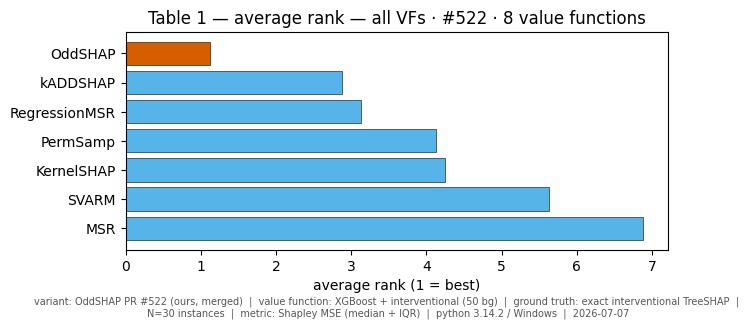

In [2]:
avg_rank, used = R.average_rank(TAB_VFS + GPU_VFS, VARIANT)
if avg_rank:
    ordered = sorted(avg_rank, key=avg_rank.get)
    print(f"Average rank over {len(used)} value functions {used}:")
    for e in ordered:
        print(f"  {e:<15} {avg_rank[e]:.2f}")
    fig, ax = plt.subplots(figsize=(7, 3.3))
    colors = [R.ODDSHAP_COLOR if e == "OddSHAP" else R.OKABE_ITO["sky"] for e in ordered] \
        if hasattr(R, "OKABE_ITO") else [R.estimator_style(e)["color"] for e in ordered]
    ax.barh(ordered, [avg_rank[e] for e in ordered], color=colors, edgecolor="black", lw=0.4)
    ax.invert_yaxis(); ax.set_xlabel("average rank (1 = best)")
    ax.set_title(R.fig_title("Table 1 — average rank", "all VFs", VARIANT, f"{len(used)} value functions"))
    R.add_banner(fig, BANNER_TAB); plt.show()

## Table 3 — expanded table with spread (median [Q1, Q3])

The paper's Appendix-A Table 3 reports the distribution, not just the mean. Rendered as a
styled table so the spread is visible at a glance for every value function.

In [3]:
tbl = R.table3_dataframe(TAB_VFS + GPU_VFS, VARIANT)
try:
    display(tbl.style.set_caption(f"Table 3 — median [Q1, Q3] of Shapley MSE · {R.VARIANT_LABEL[VARIANT]}"))
except (NameError, AttributeError):
    print(tbl)

,cancer (d=30),realestate (d=15),corrgroups60 (d=60),independentlinear60 (d=60),nhanes (d=79),crime (d=101),vit16 (d=16),distilbert (d=14)
OddSHAP,"1.92e-06 [1.4e-06, 3.4e-06]","8.59e-07 [5.6e-07, 1.6e-06]","7.29e-06 [5.8e-06, 9.4e-06]","2.56e-06 [2.1e-06, 3.0e-06]","1.41e-06 [1.1e-06, 2.5e-06]","1.42e-01 [8.0e-02, 1.9e-01]","1.15e-05 [5.3e-06, 1.7e-05]","5.21e-05 [3.1e-05, 1.1e-04]"
KernelSHAP,"2.02e-04 [1.1e-04, 3.0e-04]","2.16e-03 [1.6e-03, 3.9e-03]","1.20e-04 [8.6e-05, 1.7e-04]","1.92e-04 [1.3e-04, 2.7e-04]","5.98e-05 [4.3e-05, 1.3e-04]","2.05e+00 [1.1e+00, 4.6e+00]","8.99e-05 [5.3e-05, 1.3e-04]","1.37e-04 [6.6e-05, 4.8e-04]"
MSR,"2.82e-02 [1.2e-02, 5.4e-02]","3.85e-02 [1.9e-02, 6.1e-02]","4.45e-03 [3.4e-03, 8.8e-03]","5.66e-03 [3.9e-03, 9.6e-03]","1.38e-03 [6.4e-04, 2.0e-03]","3.65e+01 [1.7e+01, 7.1e+01]","6.09e-04 [2.4e-04, 8.7e-04]","4.15e-04 [2.1e-04, 1.7e-03]"
PermSamp,"9.84e-05 [5.7e-05, 3.1e-04]","4.57e-03 [1.9e-03, 5.8e-03]","1.00e-04 [8.4e-05, 1.4e-04]","1.28e-04 [9.3e-05, 2.2e-04]","5.94e-05 [3.9e-05, 1.1e-04]","1.80e+00 [8.6e-01, 2.9e+00]","1.98e-04 [1.1e-04, 2.6e-04]","1.02e-03 [3.5e-04, 1.2e-03]"
RegressionMSR,"4.39e-04 [3.6e-04, 5.6e-04]","9.60e-06 [5.4e-06, 1.9e-05]","1.12e-03 [8.4e-04, 1.4e-03]","1.56e-04 [1.3e-04, 1.8e-04]","2.73e-05 [1.8e-05, 3.2e-05]","2.17e+00 [1.4e+00, 2.9e+00]","1.35e-05 [6.8e-06, 2.6e-05]","3.20e-05 [1.5e-05, 8.3e-05]"
SVARM,"1.91e-03 [1.4e-03, 2.4e-03]","2.66e-02 [1.4e-02, 3.9e-02]","1.64e-03 [1.4e-03, 2.0e-03]","3.35e-03 [2.8e-03, 4.3e-03]","3.94e-04 [2.9e-04, 6.4e-04]","4.55e+00 [3.2e+00, 8.2e+00]","7.40e-05 [4.1e-05, 1.2e-04]","1.70e-04 [2.4e-05, 3.7e-04]"
kADDSHAP,"1.60e-05 [9.6e-06, 2.3e-05]","1.82e-04 [9.7e-05, 3.3e-04]","2.66e-05 [2.0e-05, 4.9e-05]","3.63e-05 [2.4e-05, 4.8e-05]","3.94e-05 [2.4e-05, 1.1e-04]","3.63e+00 [1.6e+00, 6.4e+00]","3.91e-05 [1.8e-05, 5.4e-05]","6.48e-05 [4.3e-05, 1.1e-04]"


## Figure 2 — MSE vs budget (per value function)

OddSHAP vs the sampling baselines. Log-log; median line + IQR band. Each estimator has a
fixed colour + marker + line style. OddSHAP turns on at budget ≥ n·η and drops fastest.

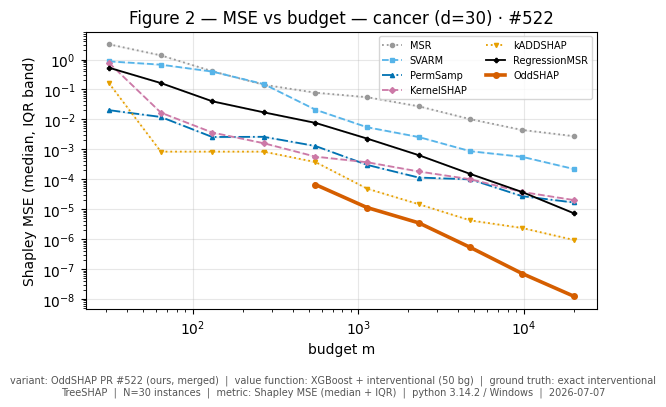

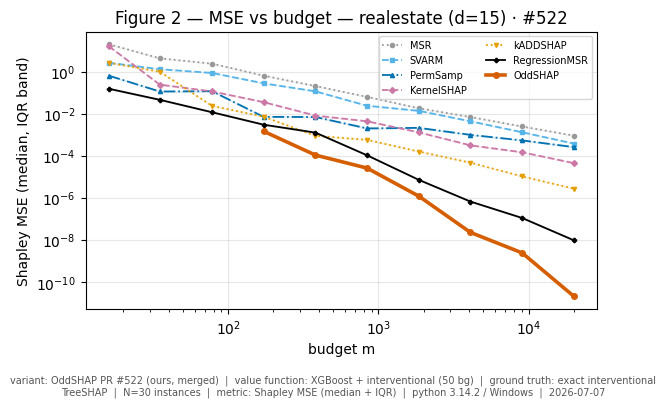

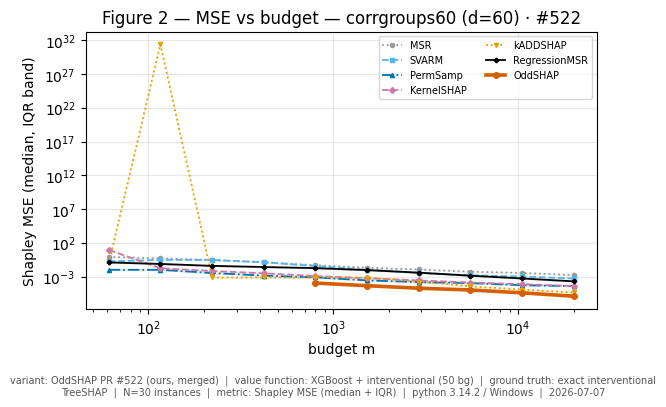

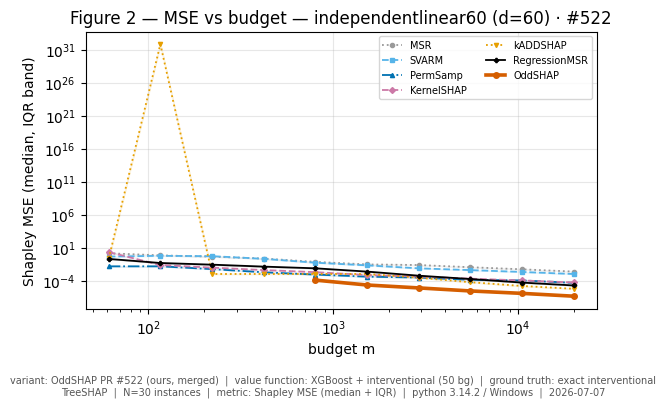

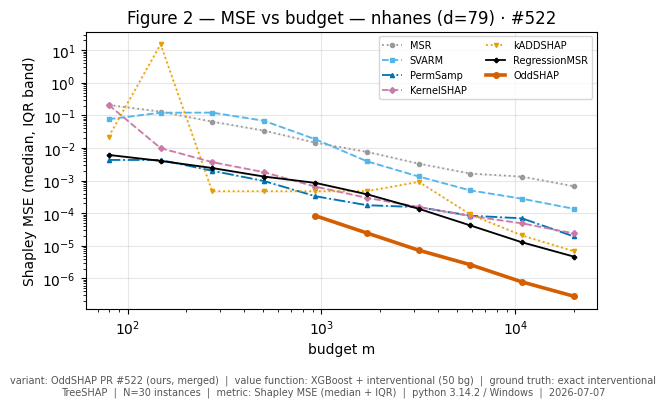

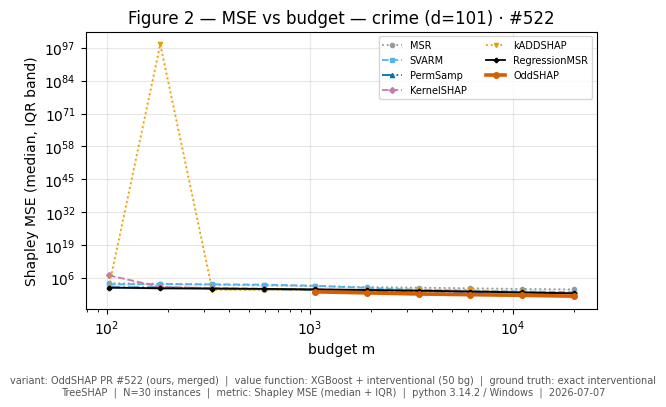

In [4]:
for vf in TAB_VFS:
    curves = R.load_fig2(vf, VARIANT)
    if not curves:
        continue
    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    for e in ESTIMATORS:
        pts = sorted(curves.get(e, {}).items())
        if not pts:
            continue
        xs = [b for b, _ in pts]
        med = np.array([v[0] for _, v in pts])
        q1 = np.array([v[1] for _, v in pts]); q3 = np.array([v[2] for _, v in pts])
        st = R.estimator_style(e)
        ax.plot(xs, np.clip(med, 1e-32, None), label=e, **st)
        ax.fill_between(xs, np.clip(q1, 1e-32, None), np.clip(q3, 1e-32, None),
                        color=st["color"], alpha=0.12)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(True, alpha=0.3)
    ax.set_xlabel("budget m"); ax.set_ylabel("Shapley MSE (median, IQR band)")
    ax.set_title(R.fig_title("Figure 2 — MSE vs budget", vf, VARIANT))
    ax.legend(fontsize=7, ncol=2)
    R.add_banner(fig, BANNER_TAB); plt.show()

## Figure 4 & Figure 11 — interaction-sparsity (η) ablation

MSE ratio vs the interaction-free baseline, at three fixed budgets (Figure 4 = 10,000;
Figure 11 = 5,000 / 20,000). U-shape: adding odd interactions helps, then over-fits.
Estate excluded (paper). Each value function has a distinct colour **and** marker **and**
line style (colour-blind-safe).

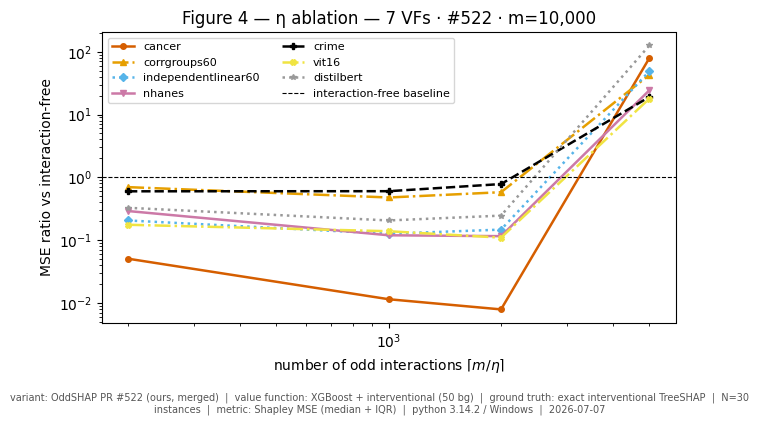

In [5]:
for budget, label in [(10_000, "Figure 4"), (5_000, "Figure 11a"), (20_000, "Figure 11c")]:
    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    any_pts = False
    for vf in TAB_VFS + GPU_VFS:
        if vf == "realestate":
            continue
        pts = R.load_eta(vf, VARIANT, budget)
        if not pts:
            continue
        any_pts = True
        ax.plot([p[0] for p in pts], [p[1] for p in pts], label=vf, **R.vf_style(vf))
    if not any_pts:
        plt.close(fig); continue
    ax.axhline(1.0, color="black", lw=0.8, ls="--", label="interaction-free baseline")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"number of odd interactions $\lceil m/\eta\rceil$")
    ax.set_ylabel("MSE ratio vs interaction-free")
    ax.set_title(R.fig_title(f"{label} — η ablation", "7 VFs", VARIANT, f"m={budget:,}"))
    ax.legend(fontsize=8, ncol=2)
    R.add_banner(fig, BANNER_TAB); plt.show()

## Figure 5 — runtime vs budget

Wall-clock runtime (median) of each estimator vs budget. Reproduces the paper's claim
that OddSHAP ≈ RegressionMSR in cost.

In [6]:
for vf in ["crime", "cancer"]:
    rt = R.load_runtime(vf, VARIANT)
    if not rt:
        continue
    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    for e in ESTIMATORS:
        pts = rt.get(e, [])
        if pts:
            ax.plot([p[0] for p in pts], [p[1] for p in pts], label=e, **R.estimator_style(e))
    ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(True, alpha=0.3)
    ax.set_xlabel("budget m"); ax.set_ylabel("runtime (s, median)")
    ax.set_title(R.fig_title("Figure 5 — runtime vs budget", vf, VARIANT))
    ax.legend(fontsize=7, ncol=2)
    R.add_banner(fig, BANNER_TAB); plt.show()

## GPU value functions — ViT16, DistilBERT

Deep-learning value functions with exact Shapley ground truth (2^16 / 2^14 evaluations).

In [7]:
for vf in GPU_VFS:
    t = R.load_table1(vf, VARIANT)
    if not t:
        continue
    print(f"\n{vf} (d={R.PAPER_D[vf]}, exact GT, budget=100·d):")
    for rk, e in enumerate(sorted(t, key=lambda e: t[e][0]), 1):
        m, q1, q3, _, _ = t[e]
        tag = "  <- OddSHAP" if e == "OddSHAP" else ""
        print(f"  {rk}. {e:<14} {m:.2e}  [IQR {q1:.1e}, {q3:.1e}]{tag}")


vit16 (d=16, exact GT, budget=100·d):
  1. OddSHAP        1.15e-05  [IQR 5.3e-06, 1.7e-05]  <- OddSHAP
  2. RegressionMSR  1.35e-05  [IQR 6.8e-06, 2.6e-05]
  3. kADDSHAP       3.91e-05  [IQR 1.8e-05, 5.4e-05]
  4. SVARM          7.40e-05  [IQR 4.1e-05, 1.2e-04]
  5. KernelSHAP     8.99e-05  [IQR 5.3e-05, 1.3e-04]
  6. PermSamp       1.98e-04  [IQR 1.1e-04, 2.6e-04]
  7. MSR            6.09e-04  [IQR 2.4e-04, 8.7e-04]

distilbert (d=14, exact GT, budget=100·d):
  1. RegressionMSR  3.20e-05  [IQR 1.5e-05, 8.3e-05]
  2. OddSHAP        5.21e-05  [IQR 3.1e-05, 1.1e-04]  <- OddSHAP
  3. kADDSHAP       6.48e-05  [IQR 4.3e-05, 1.1e-04]
  4. KernelSHAP     1.37e-04  [IQR 6.6e-05, 4.8e-04]
  5. SVARM          1.70e-04  [IQR 2.4e-05, 3.7e-04]
  6. MSR            4.15e-04  [IQR 2.1e-04, 1.7e-03]
  7. PermSamp       1.02e-03  [IQR 3.5e-04, 1.2e-03]


## Summary

Using this OddSHAP variant, the reproduction recovers the paper's headline across the
value functions produced so far: OddSHAP's rank-1 average, the Figure-2 budget scaling,
the Figure-4/11 interaction-sparsity U-shape, and the Figure-5 runtime profile. Each
figure is annotated with the exact experimental environment that produced it, and uses a
colour-blind-safe palette with redundant marker/line-style encoding.